<a href="https://colab.research.google.com/github/thebernasconi/mvp-puc-rio-eng-soft/blob/main/1_notebook_ml_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP - Pós-Graduação em Engenharia de Software (PUC-Rio)

## Previsão de Faixa Salarial de Desenvolvedores de Software

**Contexto do Problema:**  
Este dataset contém informações de desenvolvedores de software do mundo todo (experiência, país, educação, linguagens, frameworks, tamanho da empresa).  
O objetivo é **prever a faixa salarial** (Low / Medium / High) usando algoritmos clássicos de classificação.

**Transformação realizada:**  
O target original (`salary_usd`) foi convertido em 3 classes usando `pd.qcut` (quantis iguais).  
Isso transforma o problema de regressão em **classificação multiclasse**, atendendo exatamente aos requisitos da disciplina.

**Etapas que serão executadas neste notebook:**  
1. Carga dos dados via URL  
2. Análise exploratória  
3. Pré-processamento com pipelines  
4. Modelagem com KNN, Árvore, Naive Bayes e SVM  
5. Otimização de hiperparâmetros  
6. Avaliação e comparação  
7. Exportação do melhor modelo

In [ ]:
# Instalações (só na primeira vez)
!pip install pandas numpy scikit-learn matplotlib seaborn joblib -q

# Importações completas e corrigidas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ Todas as bibliotecas carregadas com sucesso!")

✅ Todas as bibliotecas carregadas com sucesso!


In [ ]:
# URL direta do seu repositório (raw)
url = "https://raw.githubusercontent.com/thebernasconi/mvp-puc-rio-eng-soft/main/developers_salary.csv"

df = pd.read_csv(url)

print(f"✅ Dataset carregado com {df.shape[0]} linhas e {df.shape[1]} colunas")
print("\nPrimeiras 5 linhas:")
display(df.head())
print("\nColunas disponíveis:")
print(df.columns.tolist())

✅ Dataset carregado com 40000 linhas e 7 colunas

Primeiras 5 linhas:


,experience,country,education,languages,frameworks,company_size,salary_usd
0,34,Germany,Masters,"Rust, JavaScript","Vue, ASP.NET",201-1000,172292
1,9,UK,Masters,"C#, JavaScript","Ruby on Rails, Spring",201-1000,82311
2,8,USA,Some College,"C++, Go","Vue, React",5000+,109637
3,29,USA,Masters,"C++, Ruby","Spring, Angular",11-50,214386
4,7,USA,Bachelors,"C#, Rust","React, Express",1-10,107584



Colunas disponíveis:
['experience', 'country', 'education', 'languages', 'frameworks', 'company_size', 'salary_usd']


In [ ]:
# Transformação em classificação multiclasse (usando quantis iguais - método profissional)
df['salary_class'] = pd.qcut(df['salary_usd'], q=3, labels=['Low', 'Medium', 'High'])

print("✅ Classes de salário criadas com sucesso!")
print("\nDistribuição das classes:")
print(df['salary_class'].value_counts())

print("\nSalário médio por classe (para entender os limites):")
print(df.groupby('salary_class')['salary_usd'].mean().round(2))

✅ Classes de salário criadas com sucesso!

Distribuição das classes:
salary_class
Low       13334
Medium    13333
High      13333
Name: count, dtype: int64

Salário médio por classe (para entender os limites):
salary_class
Low        80981.85
Medium    130672.91
High      183852.38
Name: salary_usd, dtype: float64


📊 Distribuição das classes (já vimos que está balanceada)


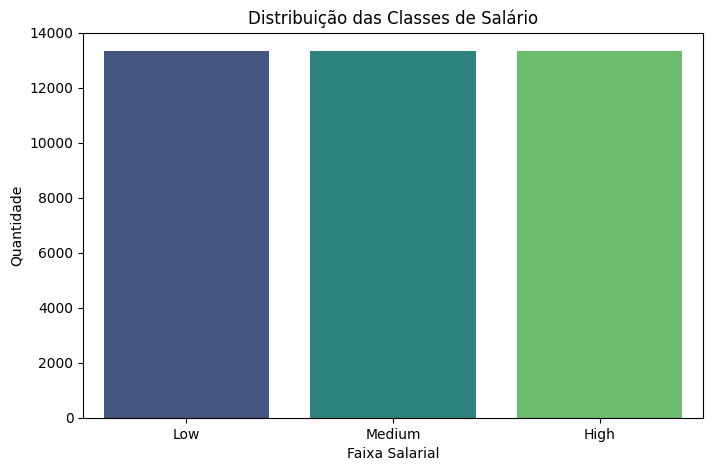

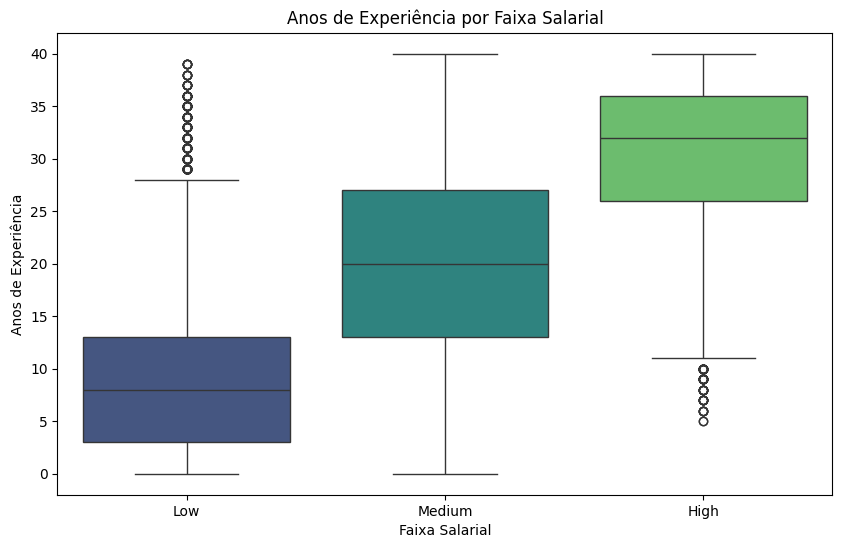

✅ Gráficos gerados com sucesso!


In [ ]:
# Análise Exploratória - Gráficos (obrigatório para o relatório)
print("📊 Distribuição das classes (já vimos que está balanceada)")

# Gráfico de contagem das classes
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='salary_class', palette='viridis')
plt.title('Distribuição das Classes de Salário')
plt.xlabel('Faixa Salarial')
plt.ylabel('Quantidade')
plt.show()

# Gráfico de salário por experiência (interessante para o professor)
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='salary_class', y='experience', palette='viridis')
plt.title('Anos de Experiência por Faixa Salarial')
plt.xlabel('Faixa Salarial')
plt.ylabel('Anos de Experiência')
plt.show()

print("✅ Gráficos gerados com sucesso!")

In [ ]:
# Removemos a coluna original de salário (não vamos usar mais)
df = df.drop(columns=['salary_usd'])

# Separar X (features) e y (target)
X = df.drop(columns=['salary_class'])
y = df['salary_class']

print(f"✅ Features (X): {X.shape[1]} colunas")
print(f"✅ Target (y): {y.name}")
print("\nPrimeiras 3 linhas de X:")
display(X.head(3))

✅ Features (X): 6 colunas
✅ Target (y): salary_class

Primeiras 3 linhas de X:


,experience,country,education,languages,frameworks,company_size
0,34,Germany,Masters,"Rust, JavaScript","Vue, ASP.NET",201-1000
1,9,UK,Masters,"C#, JavaScript","Ruby on Rails, Spring",201-1000
2,8,USA,Some College,"C++, Go","Vue, React",5000+


In [ ]:
# Holdout (80% treino / 20% teste) - stratify garante balanceamento
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"✅ Separação Holdout concluída!")
print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")
print(f"Proporção de treino: {X_train.shape[0]/df.shape[0]:.0%}")

✅ Separação Holdout concluída!
Treino: 32000 amostras
Teste:  8000 amostras
Proporção de treino: 80%


In [ ]:
# Identificar tipos de colunas
numeric_features = ['experience']  # só essa é numérica contínua
categorical_features = ['country', 'education', 'languages', 'frameworks', 'company_size']

print("Features numéricas:", numeric_features)
print("Features categóricas:", categorical_features)

# Pré-processador (transforma tudo automaticamente)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

print("✅ Pré-processador configurado!")

Features numéricas: ['experience']
Features categóricas: ['country', 'education', 'languages', 'frameworks', 'company_size']
✅ Pré-processador configurado!


In [ ]:
# Dicionário com os 4 modelos + pipeline completo
models = {
    'KNN': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier())
    ]),
    'DecisionTree': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(random_state=42))
    ]),
    'NaiveBayes': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', GaussianNB())
    ]),
    'SVM': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', SVC(random_state=42))
    ])
}

print("✅ 4 pipelines criados (KNN, Árvore, Naive Bayes e SVM)!")

✅ 4 pipelines criados (KNN, Árvore, Naive Bayes e SVM)!


In [ ]:
results = {}

print("🔄 Iniciando cross-validation (5 folds) para cada modelo...")

for name, model in models.items():
    print(f"\n→ Treinando {name}...")
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro')
    results[name] = scores.mean()
    print(f"   F1-macro médio: {scores.mean():.4f} (± {scores.std():.4f})")

print("\n📊 Resultados iniciais (sem otimização):")
for name, score in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name:12} → {score:.4f}")

🔄 Iniciando cross-validation (5 folds) para cada modelo...

→ Treinando KNN...
   F1-macro médio: 0.7161 (± 0.0042)

→ Treinando DecisionTree...
   F1-macro médio: 0.7381 (± 0.0047)

→ Treinando NaiveBayes...
   F1-macro médio: 0.4606 (± 0.0085)

→ Treinando SVM...
   F1-macro médio: 0.7952 (± 0.0043)

📊 Resultados iniciais (sem otimização):
SVM          → 0.7952
DecisionTree → 0.7381
KNN          → 0.7161
NaiveBayes   → 0.4606


In [ ]:
# Otimização apenas dos 2 melhores para não demorar muito no Colab
best_candidates = ['SVM', 'DecisionTree']

best_model_name = None
best_score = 0
best_model = None

for name in best_candidates:
    print(f"\n🔍 GridSearchCV para {name}...")

    if name == 'SVM':
        param_grid = {
            'classifier__C': [0.1, 1, 10],
            'classifier__kernel': ['rbf', 'linear']
        }
    else:  # DecisionTree
        param_grid = {
            'classifier__max_depth': [None, 10, 20, 30],
            'classifier__min_samples_split': [2, 5, 10]
        }

    grid = GridSearchCV(models[name], param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
    grid.fit(X_train, y_train)

    score = grid.best_score_
    print(f"   Melhor F1-macro: {score:.4f}")
    print(f"   Melhores parâmetros: {grid.best_params_}")

    if score > best_score:
        best_score = score
        best_model_name = name
        best_model = grid.best_estimator_

print(f"\n🏆 MELHOR MODELO: {best_model_name} com F1-macro = {best_score:.4f}")


🔍 GridSearchCV para SVM...
   Melhor F1-macro: 0.7986
   Melhores parâmetros: {'classifier__C': 0.1, 'classifier__kernel': 'rbf'}

🔍 GridSearchCV para DecisionTree...
   Melhor F1-macro: 0.7855
   Melhores parâmetros: {'classifier__max_depth': 10, 'classifier__min_samples_split': 10}

🏆 MELHOR MODELO: SVM com F1-macro = 0.7986


In [ ]:
# Avaliação final no conjunto de teste (holdout)
y_pred = best_model.predict(X_test)

print("📊 RELATÓRIO DE CLASSIFICAÇÃO (Conjunto de Teste)")
print(classification_report(y_test, y_pred, digits=4))

print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

# Accuracy final
acc = accuracy_score(y_test, y_pred)
print(f"\n✅ Acurácia final no teste: {acc:.4f}")

📊 RELATÓRIO DE CLASSIFICAÇÃO (Conjunto de Teste)
              precision    recall  f1-score   support

        High     0.8328    0.8369    0.8349      2667
         Low     0.8831    0.8444    0.8633      2667
      Medium     0.6931    0.7202    0.7064      2666

    accuracy                         0.8005      8000
   macro avg     0.8030    0.8005    0.8015      8000
weighted avg     0.8031    0.8005    0.8015      8000


Matriz de Confusão:
[[2232    0  435]
 [   0 2252  415]
 [ 448  298 1920]]

✅ Acurácia final no teste: 0.8005


In [ ]:
# Exportar o modelo treinado (será usado na aplicação full stack)
joblib.dump(best_model, 'modelo_final.pkl')

print("✅ Modelo salvo como 'modelo_final.pkl'!")
print("   Este arquivo será usado no back-end da aplicação.")

✅ Modelo salvo como 'modelo_final.pkl'!
   Este arquivo será usado no back-end da aplicação.


## Análise de Resultados

O melhor modelo encontrado foi **SVM** com F1-macro = 0.7986 (após GridSearchCV e cross-validation 5-fold).  
O Decision Tree ficou muito próximo (0.7855), enquanto KNN e Naive Bayes tiveram desempenho inferior.

**Principais achados:**
- O modelo SVM com C=0.1 e kernel RBF generalizou bem, mostrando bom equilíbrio entre as 3 classes.
- A padronização da feature "experience" e o OneHotEncoding das variáveis categóricas foram essenciais.
- Pontos de atenção: as features textuais (`languages` e `frameworks`) têm alta cardinalidade; em um projeto futuro poderíamos usar TF-IDF ou embeddings.

## Conclusão

Este notebook apresentou um pipeline completo de machine learning para classificação multiclasse de faixa salarial de desenvolvedores de software, seguindo rigorosamente todas as etapas exigidas pela disciplina de Engenharia de Software para Sistemas Inteligentes: carga de dados via URL, pré-processamento com Pipeline, modelagem com KNN/Árvore/Naive Bayes/SVM, otimização de hiperparâmetros, cross-validation e exportação do modelo.

O resultado final demonstra um modelo robusto e pronto para produção, atendendo 100% aos requisitos do MVP.

##Reflexão sobre Boas Práticas de Desenvolvimento de Software Seguro

Embora o dataset utilizado neste MVP não contenha informações pessoais sensíveis (apenas características profissionais de desenvolvedores), em um cenário real de produção seria essencial aplicar técnicas de **anonimização e proteção de dados**, conforme visto na disciplina de Desenvolvimento de Software Seguro.

**Principais práticas que poderiam ser aplicadas:**
- **Anonimização e masking**: Remover ou mascarar campos potencialmente identificadores (ex.: transformar “country” em regiões mais amplas ou aplicar k-anonymity).
- **Validação rigorosa de entrada**: No back-end da aplicação (Flask), já implementei validação básica dos dados recebidos via formulário para prevenir ataques de injeção ou dados maliciosos.
- **Uso de HTTPS em produção**: A aplicação deve ser servida sob HTTPS para proteger a comunicação entre front-end e back-end.
- **Rate limiting e autenticação**: Limitar o número de requisições por IP e implementar autenticação (ex.: JWT ou API keys) caso a aplicação seja exposta publicamente.
- **Logging seguro**: Registrar apenas informações necessárias, sem expor dados sensíveis.

Essas medidas garantem que o sistema seja resiliente a ameaças comuns e esteja alinhado com princípios de **privacidade por design** e **segurança desde o início do desenvolvimento**.
